## DQN
- 구글의 딥마인드 "Playing Atari with Deep Reinforcement Learning" 이라는 논문에서 제안됨.
- 오프폴리시 알고리즘인 큐러닝과 인공신겸망을 함께 사용하기 위하여 **경험 리플레이**를 사용함.

### 경험 리플레이(Experience Replay)
- 리플레이 메모리(Replay Memory): 에이전트가 환경에서 탐험하며 얻는 샘플($s$, $a$, $r$, $s'$)을 저장한 메모리
- 에이전트가 학습할 떄는 리플레이 메모리에서 여러개의 샘플을 무작위로 뽑고 해당 샘플을 업데이트에 사용하며 이를 매 타임스텝마다 반복
- 샘플 간의 상관관계를 없앨 수 있음.
    - 딥살사 같은 온폴리시 알고리즘은 안 좋은 상황에 빠질 때 그 상황에 맞게 학습됨.
    - 리플레이 메모리를 사용하면 학습할 샘플들이 시간적인 상관관계가 없으므로 그런 일이 발생하지 않는다.
- 리플레이 메모리에서 추출한 여러개의 샘플을 통해 업데이트하므로 학습이 안정적임.(like 미니배치)
- 여러개의 데이터에서 그레디언트를 구하면 하나에서 구하는것보다 값 변화량이 줄어 좀 더 안정적으로 학습됨.
- 오프폴리시 알고리즘인 큐러닝 알고리즘을 함께 사용
    - 현재 정책으로 부터 발생한 상황으로 학습하는 것이 아닌 과거의 정책/상황으로 학습하기 때문에 오프폴리시 알고리즘이 적합

### 타겟 신경망
- DQN에서 사용하는 오류함수는 **MSE**
    - $MSE = (\text{정답} - \text{예측})^2 = (R_{t+1} + \gamma \cdot \text{max} Q(s', a', \theta) - Q(s, a, \theta))^2$
- 부트스트랩: 추정치를 바탕으로 또 다른 추정치를 업데이트 하는 방식
    - 문제점: 업데이트의 목표가 되는 정답이 계속 변하며 정답을 내는 인공신경망 자체도 계속 업데이트 된다.
    - 해결: 정답을 만들어내는 인공신경망을 일정 시간 동안 유지 
- 이를 구분한 MSE식은 다음과 같다.($\theta ^{-}$: 타겟신경망, $\theta$: 인공신경망)
    - $MSE = (\text{정답} - \text{예측})^2 = (R_{t+1} + \gamma \cdot \text{max} Q(s', a', \theta ^ {-}) - Q(s, a, \theta))^2$

### DQN의 에이전트와 환경의 상호작용
1) 상황에 따른 행동 선택
2) 선택한 행동으로 환경에서 한 타임스텝 진행
3) 환경으로부터 다음 상태와 보상을 받음
4) 샘플($s$, $a$, $r$, $s'$)을 리플레이 메모리에 저장
5) 리플레이 메모리에서 무작위 추출한 샘플로 학습
6) 에피소드(혹은 특정 타임 스텝)마다 타겟 모델 업데이트

c:\Users\0627j\anaconda3\envs\RL\lib\site-packages\gym\logger.py:30: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize('%s: %s'%('WARN', msg % args), 'yellow'))


episode:   0 | score avg: 15.00 | memory length:   15 | epsilon: 1.0000
episode:   1 | score avg: 15.70 | memory length:   37 | epsilon: 1.0000
episode:   2 | score avg: 16.83 | memory length:   64 | epsilon: 1.0000
episode:   3 | score avg: 17.55 | memory length:   88 | epsilon: 1.0000
episode:   4 | score avg: 17.59 | memory length:  106 | epsilon: 1.0000
episode:   5 | score avg: 21.43 | memory length:  162 | epsilon: 1.0000
episode:   6 | score avg: 22.09 | memory length:  190 | epsilon: 1.0000
episode:   7 | score avg: 22.58 | memory length:  217 | epsilon: 1.0000
episode:   8 | score avg: 21.82 | memory length:  232 | epsilon: 1.0000
episode:   9 | score avg: 20.84 | memory length:  244 | epsilon: 1.0000
episode:  10 | score avg: 22.26 | memory length:  279 | epsilon: 1.0000
episode:  11 | score avg: 25.53 | memory length:  334 | epsilon: 1.0000
episode:  12 | score avg: 24.28 | memory length:  347 | epsilon: 1.0000
episode:  13 | score avg: 24.25 | memory length:  371 | epsilon:

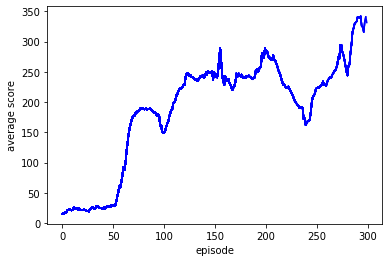

In [1]:
import os
import sys
import gym
import pylab
import random
import numpy as np
from collections import deque
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomUniform

# 상태가 입력, 큐함수가 출력인 인공신경망 생성
class DQN(tf.keras.Model):
    def __init__(self, action_size):
        super(DQN, self).__init__()
        self.fc1 = Dense(24, activation='relu')
        self.fc2 = Dense(24, activation='relu')
        self.fc_out = Dense(action_size,
                            kernel_initializer=RandomUniform(-1e-3, 1e-3))

    def call(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        q = self.fc_out(x)
        return q


# 카트폴 예제에서의 DQN 에이전트
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.render = False

        # 상태와 행동의 크기 정의
        self.state_size = state_size
        self.action_size = action_size

        # DQN 하이퍼파라미터
        self.discount_factor = 0.99
        self.learning_rate = 0.001
        self.epsilon = 1.0
        self.epsilon_decay = 0.999
        self.epsilon_min = 0.01 # 입실론 값이 1부터 시작해서 0.999의 비율로 0.01까지 감소함.
        self.batch_size = 64
        self.train_start = 1000

        # 리플레이 메모리, 최대 크기 2000
        self.memory = deque(maxlen=2000)

        # 모델과 타깃 모델 생성
        self.model = DQN(action_size)
        self.target_model = DQN(action_size)
        self.optimizer = Adam(lr=self.learning_rate)

        # 타깃 모델 초기화
        self.update_target_model()

    # 타깃 모델을 모델의 가중치로 업데이트
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    # 입실론 탐욕 정책으로 행동 선택
    def get_action(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        else:
            q_value = self.model(state)
            return np.argmax(q_value[0])

    # 샘플 <s, a, r, s'>을 리플레이 메모리에 저장
    def append_sample(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    # 리플레이 메모리에서 무작위로 추출한 배치로 모델 학습
    def train_model(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        # 메모리에서 배치 크기만큼 무작위로 샘플 추출
        mini_batch = random.sample(self.memory, self.batch_size)

        states = np.array([sample[0][0] for sample in mini_batch])
        actions = np.array([sample[1] for sample in mini_batch])
        rewards = np.array([sample[2] for sample in mini_batch])
        next_states = np.array([sample[3][0] for sample in mini_batch])
        dones = np.array([sample[4] for sample in mini_batch])

        # 학습 파라메터
        model_params = self.model.trainable_variables
        with tf.GradientTape() as tape:
            # 현재 상태에 대한 모델의 큐함수
            predicts = self.model(states)
            one_hot_action = tf.one_hot(actions, self.action_size)

            predicts = tf.reduce_sum(one_hot_action * predicts, axis=1)

            # 다음 상태에 대한 타깃 모델의 큐함수
            target_predicts = self.target_model(next_states)
            target_predicts = tf.stop_gradient(target_predicts)

            # 벨만 최적 방정식을 이용한 업데이트 타깃
            max_q = np.amax(target_predicts, axis=-1)
            targets = rewards + (1 - dones) * self.discount_factor * max_q
            loss = tf.reduce_mean(tf.square(targets - predicts))

        # 오류함수를 줄이는 방향으로 모델 업데이트
        grads = tape.gradient(loss, model_params)
        self.optimizer.apply_gradients(zip(grads, model_params))


# CartPole-v1 환경, 최대 타임스텝 수가 500
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# DQN 에이전트 생성
agent = DQNAgent(state_size, action_size)

scores, episodes = [], []
score_avg = 0

num_episode = 300
for e in range(num_episode):
    done = False
    score = 0
    # env 초기화
    state = env.reset()
    state = np.reshape(state, [1, state_size])

    while not done:
        if agent.render:
            env.render()

        # 현재 상태로 행동을 선택
        action = agent.get_action(state)
        # 선택한 행동으로 환경에서 한 타임스텝 진행
        next_state, reward, done, info = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])

        # 타임스텝마다 보상 0.1, 에피소드가 중간에 끝나면 -1 보상
        score += reward
        reward = 0.1 if not done or score == 500 else -1

        # 리플레이 메모리에 샘플 <s, a, r, s'> 저장
        agent.append_sample(state, action, reward, next_state, done)
        # 매 타임스텝마다 학습
        if len(agent.memory) >= agent.train_start:
            agent.train_model()

        state = next_state

        if done:
            # 각 에피소드마다 타깃 모델을 모델의 가중치로 업데이트
            agent.update_target_model()
            # 에피소드마다 학습 결과 출력
            score_avg = 0.9 * score_avg + 0.1 * score if score_avg != 0 else score
            print("episode: {:3d} | score avg: {:3.2f} | memory length: {:4d} | epsilon: {:.4f}".format(
                    e, score_avg, len(agent.memory), agent.epsilon))

            # 에피소드마다 학습 결과 그래프로 저장
            scores.append(score_avg)
            episodes.append(e)
            pylab.plot(episodes, scores, 'b')
            pylab.xlabel("episode")
            pylab.ylabel("average score")
            pylab.savefig("data/saved/graph.png")

            # 이동 평균이 400 이상일 때 종료
            if score_avg > 400:
                agent.model.save_weights("./save_model/model", save_format="tf")
                sys.exit()

In [ ]:
import sys
import gym
import pylab
import random
import numpy as np
from collections import deque
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomUniform

# 상태가 입력, 큐함수가 출력인 인공신경망 생성
class DQN(tf.keras.Model):
    def __init__(self, action_size):
        super(DQN, self).__init__()
        self.fc1 = Dense(24, activation='relu')
        self.fc2 = Dense(24, activation='relu')
        self.fc_out = Dense(action_size,
                            kernel_initializer=RandomUniform(-1e-3, 1e-3))
    def call(self, x):
            x = self.fc1(x)
            x = self.fc2(x)
            q = self.fc_out(x)
            return q


# 카트폴 예제에서의 DQN 에이전트
class DQNAgent:
    def __init__(self, state_size, action_size):
        # 상태와 행동의 크기 정의
        self.state_size = state_size
        self.action_size = action_size

        # 모델과 타깃 모델 생성
        self.model = DQN(action_size)
        self.model.load_weights("./save_model/model")

    # 입실론 탐욕 정책으로 행동 선택
    def get_action(self, state):
        q_value = self.model(state)
        return np.argmax(q_value[0])

# CartPole-v1 환경, 최대 타임스텝 수가 500
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

# DQN 에이전트 생성
agent = DQNAgent(state_size, action_size)

num_episode = 10
for e in range(num_episode):
    done = False
    score = 0
    # env 초기화
    state = env.reset()
    state = np.reshape(state, [1, state_size])

    while not done:
        env.render()


        # 현재 상태로 행동을 선택
        action = agent.get_action(state)
        # 선택한 행동으로 환경에서 한 타임스텝 진행
        next_state, reward, done, info = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])

        score += reward
        state = next_state

        if done:
            # 에피소드마다 학습 결과 출력
            print("episode: {:3d} | score: {:.3f} ".format(e, score))

print("종료됨.")


If you intended to run this layer in float32, you can safely ignore this warning. If in doubt, this warning is likely only an issue if you are porting a TensorFlow 1.X model to TensorFlow 2.

To change all layers to have dtype float64 by default, call `tf.keras.backend.set_floatx('float64')`. To change just this layer, pass dtype='float64' to the layer constructor. If you are the author of this layer, you can disable autocasting by passing autocast=False to the base Layer constructor.

episode:   0 | score: 500.000 
episode:   1 | score: 500.000 
episode:   2 | score: 500.000 
episode:   3 | score: 500.000 
episode:   4 | score: 500.000 
episode:   5 | score: 500.000 
episode:   6 | score: 500.000 
episode:   7 | score: 500.000 
episode:   8 | score: 500.000 
episode:   9 | score: 500.000 
종료됨.


: 

In [ ]:
import sys
import gym
import pylab
import random
import numpy as np
from collections import deque
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomUniform

class DQN(tf.keras.Model):
    def __init__(self, action_size):
        super(DQN, self).__init__()
        self.fc1 = Dense(24, activation='relu')
        self.fc2 = Dense(24, activation='relu')
        self.fc_out = Dense(action_size,
                            kernel_initializer=RandomUniform(-1e-3, 1e-3))
    def call(self, x):
            x = self.fc1(x)
            x = self.fc2(x)
            q = self.fc_out(x)
            return q

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.model = DQN(action_size)
        self.model.load_weights("./save_model/model")

    def get_action(self, state):
        q_value = self.model(state)
        return np.argmax(q_value[0])

env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

agent = DQNAgent(state_size, action_size)

num_episode = 10
for e in range(num_episode):
    done = False
    score = 0
    state = env.reset()
    state = np.reshape(state, [1, state_size])

    while not done:
        env.render()

        action = agent.get_action(state)
        next_state, reward, done, info = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])

        score += reward
        state = next_state

        if done:
            print("episode: {:3d} | score: {:.3f} ".format(e, score))

print("종료됨.")